In [1]:
%load_ext autoreload
%autoreload 2
import os
import subprocess

import numpy as np
import polars as pl
import xarray as xr
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from src.samples import load_gpm_dyamond_features
from src.paths import DATA_DIR
from src.plotting import combine_cmaps, discrete_cmap
from src.saving import save_figure
from src.secrets import GPM_PASS, GPM_USER

In [2]:
# granule / label of each old pick. The label is what scipy.ndimage.label assigns the
# feature when the current definition is applied to the granule -- the same integer the
# old table called feature_id, and the tail of the current feature_id.
EXAMPLES = {
    "low_concentration": dict(
        region="H01", year="2020", month="10", time_index=0, label=9,
        granule="GPM2Ku7_uw4_20201018.234551_to_20201018.235125_037729_H01.nc",
    ),
    "high_concentration": dict(
        region="H01", year="2022", month="09", time_index=0, label=42,
        granule="GPM2Ku7_uw4_20220904.141108_to_20220904.141734_048395_H01.nc",
    ),
}

In [3]:
def _download_granule(spec):
    """Fetch the granule of an example, unless it is already on disk.

    The UW archive is laid out by region, year and month, all of which the current
    ``source_file`` carries, e.g. ".../data/gpm_v07/AFC/2015/02/GPM2Ku7_uw4_..._AFC.nc".
    """
    _GRANULE_DIR = DATA_DIR / "example_data"
    outfile = _GRANULE_DIR / spec["granule"]
    if not os.path.exists(outfile):
        url = (f"{_GPM_ARCHIVE_URL}/v07/{spec['region']}/interp_data/"
               f"{spec['year']}/{spec['month']}/{spec['granule']}")
        os.makedirs(_GRANULE_DIR, exist_ok=True)
        subprocess.run(
            ["wget", "-q", "--user", GPM_USER, "--password", GPM_PASS, url, "-O", str(outfile)],
            check=True,
        )
    return outfile

def _extract_feature(spec, threshold, res):
    """Re-label an example's granule and return the granule cut to that one feature.

    Re-running the current definition on the granule reproduces exactly the feature its
    label refers to. Every pixel outside the feature is set to NaN, and the granule is cut
    to the feature's bounding box.
    """
    swath = xr.open_dataset(_download_granule(spec)).isel(time=spec["time_index"])
    if res == "0p1":
        # The 0.1 deg feature stats are built from the native 0.05 deg grid this way
        swath = swath.coarsen(lat=2, lon=2, boundary="trim").mean()
    else:
        assert res == "0p05", f"res must be '0p05' (native) or '0p1', got {res}"

    rain = swath["near_surf_rain"]
    labels, _ = ndi.label(rain.values > threshold, structure=np.ones((3, 3), int))
    labels_da = rain.copy(data=labels)
    label_slices = ndi.find_objects(labels)
    bounding_dict = {
        d: sl for d, sl in zip(labels_da.dims, label_slices[spec["label"] - 1])
    }
    feature_data = swath.where((labels_da == spec["label"]), drop=False).isel(bounding_dict)
    return feature_data


def _feature_stats(feature, res):
    """The pipeline's statistics for one extracted feature, in the current schema.

    Lets a feature outside the current feature tables be plotted by the same code as a row
    of `load_gpm_feature_stats`: same column names, same definitions. Pixel areas are
    cosine-weighted, and cores are 8-connected pixels at or above 10 mm/hr.
    """
    rain = feature["near_surf_rain"]
    mask = rain.notnull().values
    lat = rain["lat"].broadcast_like(rain).values
    res_deg = float(res.replace("p", "."))
    _EARTH_RADIUS_KM = 6371
    px_area = (_EARTH_RADIUS_KM * np.deg2rad(res_deg)) ** 2 * np.cos(np.deg2rad(lat))

    core_mask = (rain.values >= 10) & mask
    core_labels, n_cores = ndi.label(core_mask, structure=np.ones((3, 3), int))
    core_sizes = np.bincount(core_labels.ravel())[1:]

    lon = rain["lon"].broadcast_like(rain).values
    weights = np.cos(np.deg2rad(lat[mask]))
    return pl.DataFrame({
        "size_px": int(mask.sum()),
        "area_km2": float(px_area[mask].sum()),
        "centroid_lat": float(np.average(lat[mask], weights=weights)),
        "centroid_lon": float(np.average(lon[mask], weights=weights)),
        "max_precip_mm_hr": float(np.nanmax(rain.values[mask])),
        "px_ge_10mmhr": int(core_mask.sum()),
        "n_cores_10mmhr": int(n_cores),
        "largest_core_10mmhr_px": int(core_sizes.max()) if n_cores else 0,
    })

from matplotlib.collections import LineCollection
import matplotlib.lines as mlines


def _mask_edge_segments(mask_da, lat_name="lat", lon_name="lon"):
    """Line segments along the pixel edges bounding `mask_da`, as (lon, lat) pairs.

    Coordinates are treated as cell centers (same convention xarray's pcolormesh
    plotting uses), so edges sit half a grid spacing either side.
    """
    def _edges(c):
        d = np.diff(c).mean()          # signed: handles descending coords too
        return np.concatenate([c - d / 2, [c[-1] + d / 2]])

    lat_e = _edges(mask_da[lat_name].values)
    lon_e = _edges(mask_da[lon_name].values)

    m = mask_da.transpose(lat_name, lon_name).values.astype(bool)
    p = np.pad(m, 1, constant_values=False)

    segs = []
    # boundaries between horizontally adjacent cells -> vertical segments
    ii, jj = np.nonzero(p[1:-1, :-1] != p[1:-1, 1:])
    segs += [[(lon_e[j], lat_e[i]), (lon_e[j], lat_e[i + 1])] for i, j in zip(ii, jj)]
    # boundaries between vertically adjacent cells -> horizontal segments
    ii, jj = np.nonzero(p[:-1, 1:-1] != p[1:, 1:-1])
    segs += [[(lon_e[j], lat_e[i]), (lon_e[j + 1], lat_e[i])] for i, j in zip(ii, jj)]
    return segs

_CORE_THRESHOLD = 10.0

def _core_split_cmap_norm(vmin=1.0, vmax=100.0, threshold=_CORE_THRESHOLD,
                          n_below=12, n_above=12):
    """Discrete log-spaced colors whose winter/autumn split sits exactly on `threshold`.

    The threshold is a level boundary by construction, so the color change is the
    core definition rather than an artifact of where the bins happened to land.
    """
    levels = np.concatenate([
        np.geomspace(vmin, threshold, n_below + 1),
        np.geomspace(threshold, vmax, n_above + 1)[1:],
    ])
    cmap = colors.ListedColormap(np.vstack([
        plt.get_cmap("winter")(np.linspace(0, 1, n_below)),
        plt.get_cmap("autumn")(np.linspace(0, 1, n_above)),
    ]))
    cmap.set_bad("0.75")
    return cmap, colors.BoundaryNorm(levels, cmap.N)



def _plot_example_feature(feature, feature_df, plot_title=None, pad_degs=1):
    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    # Plot the precipitation rates
    cmap, norm = _core_split_cmap_norm()
    im = feature.near_surf_rain.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )
    cbar = fig.colorbar(
        im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04,
        spacing="uniform", ticks=[1, _CORE_THRESHOLD, 100],
    )
    cbar.set_label("Precip rate (mm/hr)", fontsize=14)
    cbar.ax.tick_params(labelsize=14)

    ##
    # Plot the principal core
    #
    core_mask = (feature.near_surf_rain >= 10)
    structure = np.ones((3, 3), dtype=int)
    core_labels_arr, core_count = ndi.label(core_mask.data, structure=structure)
    assert(core_count > 0)

    # Find the largest core
    sizes = ndi.sum(core_mask.data, labels=core_labels_arr, index=range(1, core_count + 1))
    largest_label = int(np.argmax(sizes) + 1)
    largest_mask = xr.DataArray(
        (core_labels_arr == largest_label),
        coords=core_mask.coords, dims=core_mask.dims
    )
    largest_mask.plot.contourf(
        ax=ax,
        levels=[-0.5, 0.5, 1.5],
        hatches=['', '//'],   # no hatch for 0, slashes for 1
        colors='none',         # only hatches, no color fill
        add_colorbar=False
    )
    # Make a dummy patch for legend purposes
    hatch_patch = mpatches.Patch(
        facecolor='none', edgecolor='k', hatch='///', label='Largest core'
    )
    ax.legend(handles=[hatch_patch], loc='upper left')

    # Add padding around the feature centroid
    clat = feature_df['centroid_lat'].item()
    clon = feature_df['centroid_lon'].item()
    lat_min = max(-90, clat - pad_degs)
    lat_max = min(90,  clat + pad_degs)
    lon_min = (clon - pad_degs)
    lon_max = (clon + pad_degs)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_facecolor("0.75")  # dark gray map background
    im.cmap.set_bad("0.75")   # make NaN areas match the background

    # Add some annotations of the feature statistics. Area is now the pipeline's
    # cosine-weighted area_km2 rather than a pixel count times a fixed factor.
    s = (
        fr"$A = {feature_df['area_km2'].item():0.0f}$ km$^2$" + "\n"
        fr"$\sigma_{{conv}} = {(feature_df['px_ge_10mmhr'] / feature_df['size_px']).item():0.2f}$" + "\n"
        fr"$\rho_{{conv}} = {(feature_df['largest_core_10mmhr_px'] / feature_df['px_ge_10mmhr']).item():0.2f}$" + "\n"
        f"MaxPr: {feature_df['max_precip_mm_hr'].item():0.1f}mm/h"
    )
    ax.text(
        0.2, 0.875,
        s=s,
        transform=ax.transAxes,
        fontsize=12,
        linespacing=1.5,
        verticalalignment='top',
        horizontalalignment='center',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.1')
    )

    # Add coastlines + gridlines
    ax.coastlines(linewidth=0.6)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.75,
        alpha=0.5,
        linestyle="-",
        color='darkgray'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.MultipleLocator(0.25)
    gl.ylocator = mticker.MultipleLocator(0.25)
    gl.xlabel_style = {"size": 14, "rotation": 45, "ha": "right"}
    gl.ylabel_style = {"size": 14}

    ax.set_title(plot_title)
    return fig, ax

low_concentration: rho_conv = 0.43
shape: (1, 8)
┌─────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ size_px ┆ area_km2   ┆ centroid_l ┆ centroid_l ┆ max_precip ┆ px_ge_10mm ┆ n_cores_1 ┆ largest_c │
│ ---     ┆ ---        ┆ at         ┆ on         ┆ _mm_hr     ┆ hr         ┆ 0mmhr     ┆ ore_10mmh │
│ i64     ┆ f64        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ r_px      │
│         ┆            ┆ f64        ┆ f64        ┆ f64        ┆ i64        ┆ i64       ┆ ---       │
│         ┆            ┆            ┆            ┆            ┆            ┆           ┆ i64       │
╞═════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 190     ┆ 5792.99055 ┆ 9.464657   ┆ -117.71455 ┆ 89.580711  ┆ 30         ┆ 6         ┆ 13        │
│         ┆ 5          ┆            ┆ 4          ┆            ┆            ┆           ┆           │
└─────────┴────────────┴────────────┴─────

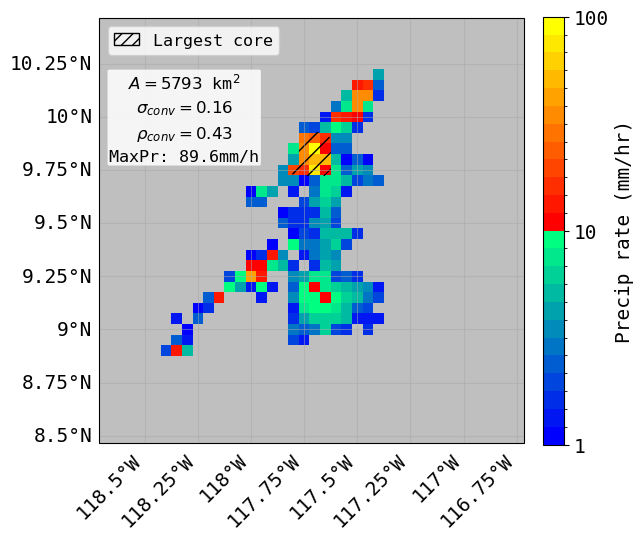

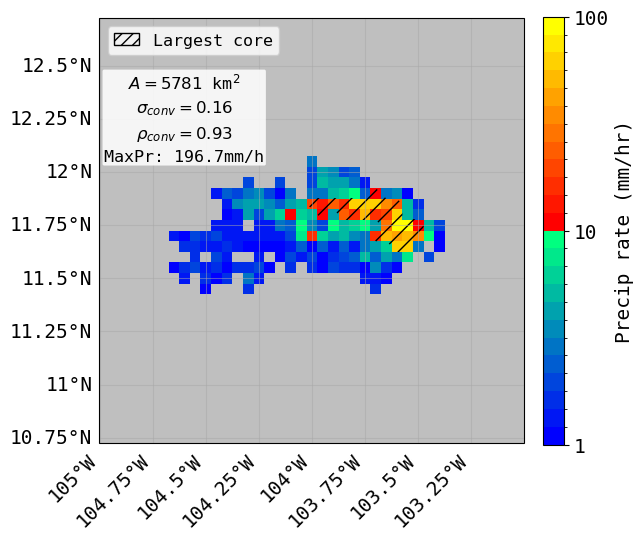

In [4]:
for name, spec in EXAMPLES.items():
    feature = _extract_feature(spec, threshold=1.0, res='0p05')
    stats = _feature_stats(feature, res='0p05')
    print(f"{name}: rho_conv = "
          f"{(stats['largest_core_10mmhr_px'] / stats['px_ge_10mmhr']).item():0.2f}")
    print(stats)

    fig, ax = _plot_example_feature(feature, stats, pad_degs=1)
    save_figure(fig, f"Example_Feature_{name.title().replace('_', '')}.pdf")